# Random Forest Project - Lending Club

For this project we will be exploring publicly available data from [LendingClub.com](www.lendingclub.com). Lending Club connects people who need money (borrowers) with people who have money (investors). Hopefully, as an investor you would want to invest in people who showed a profile of having a high probability of paying you back. We will try to create a model that will help predict this.

Lending club had a [very interesting year in 2016](https://en.wikipedia.org/wiki/Lending_Club#2016), so let's check out some of their data and keep the context in mind. This data is from before they even went public.

We will use lending data from 2007-2010 and be trying to classify and predict whether or not the borrower paid back their loan in full. 

# About the Data
* credit.policy: 1 if the customer meets the credit underwriting criteria of LendingClub.com, and 0 otherwise.
* purpose: The purpose of the loan (takes values "credit_card", "debt_consolidation", "educational", "major_purchase", "small_business", and "all_other").
* int.rate: The interest rate of the loan, as a proportion (a rate of 11% would be stored as 0.11). Borrowers judged by LendingClub.com to be more risky are assigned higher interest rates.
* installment: The monthly installments owed by the borrower if the loan is funded.
* log.annual.inc: The natural log of the self-reported annual income of the borrower.
* dti: The debt-to-income ratio of the borrower (amount of debt divided by annual income).
* fico: The FICO credit score of the borrower.
* days.with.cr.line: The number of days the borrower has had a credit line.
* revol.bal: The borrower's revolving balance (amount unpaid at the end of the credit card billing cycle).
* revol.util: The borrower's revolving line utilization rate (the amount of the credit line used relative to total credit available).
* inq.last.6mths: The borrower's number of inquiries by creditors in the last 6 months.
* delinq.2yrs: The number of times the borrower had been 30+ days past due on a payment in the past 2 years.
* pub.rec: The borrower's number of derogatory public records (bankruptcy filings, tax liens, or judgments).

In [3]:
# importing the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [51]:
# Get the data 
loans = pd.read_csv('loan_data.csv')
loans.head()


,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


In [5]:
loans.info() # to get the information about the data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   object 
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  not.fully.paid     9578 non-null   int64  
dtypes: float64(6), int64(7), object(1)
memory usage: 1.0+ MB


# EDA

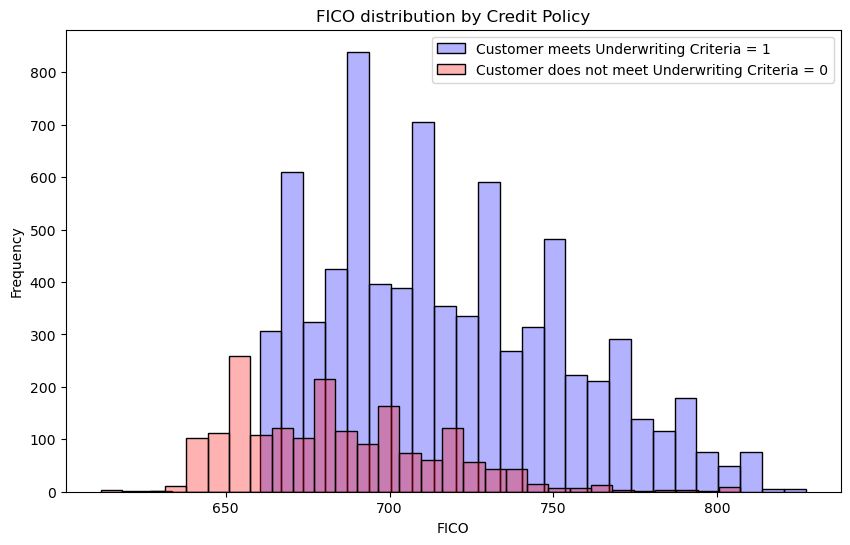

In [10]:
# Create a histogram of two FICO distributions on top of each other, 
# one for each credit.policy outcome
plt.figure(figsize=(10,6))
sns.histplot(loans[loans['credit.policy']==1]['fico'], bins=30, color='blue',
              label='Customer meets Underwriting Criteria = 1', alpha=0.3)
sns.histplot(loans[loans['credit.policy']==0]['fico'], bins=30, color='red',
              label='Customer does not meet Underwriting Criteria = 0', alpha=0.3)
plt.legend()
plt.xlabel('FICO')
plt.ylabel('Frequency')
plt.title('FICO distribution by Credit Policy')
plt.show()

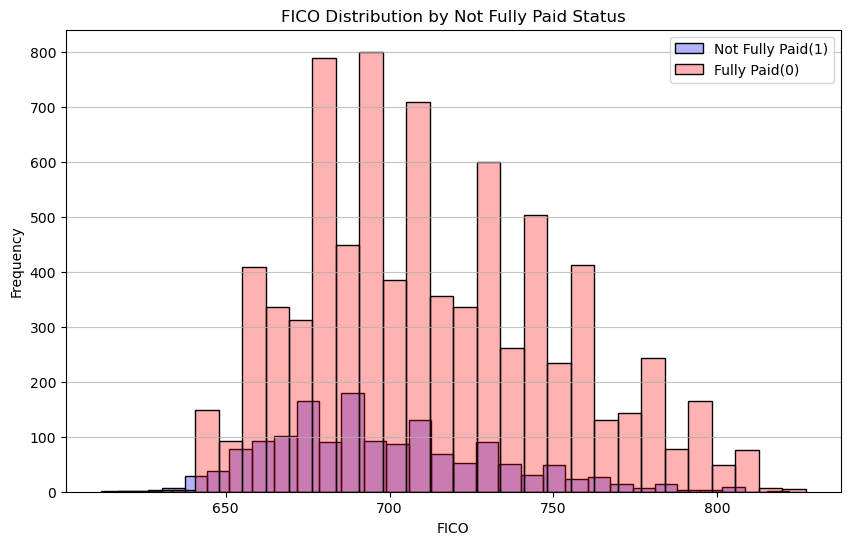

In [11]:
# Does FICO score impacts the Debt Default status of the loan?

# Plotting the histogram of two FICO distributions on top of each other,
# one for each not.fully.paid outcome
plt.figure(figsize=(10,6))
sns.histplot(loans[loans['not.fully.paid']==1]['fico'], bins=30, color='blue',
              label='Not Fully Paid(1)', alpha=0.3)
sns.histplot(loans[loans['not.fully.paid']==0]['fico'], bins=30, color='red',
              label='Fully Paid(0)', alpha=0.3)
plt.legend()
plt.xlabel('FICO')
plt.ylabel('Frequency')
plt.title('FICO Distribution by Not Fully Paid Status')
plt.grid(axis='y', alpha=0.75)
plt.show()


In [12]:
loans.head()

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


<Figure size 1000x600 with 0 Axes>

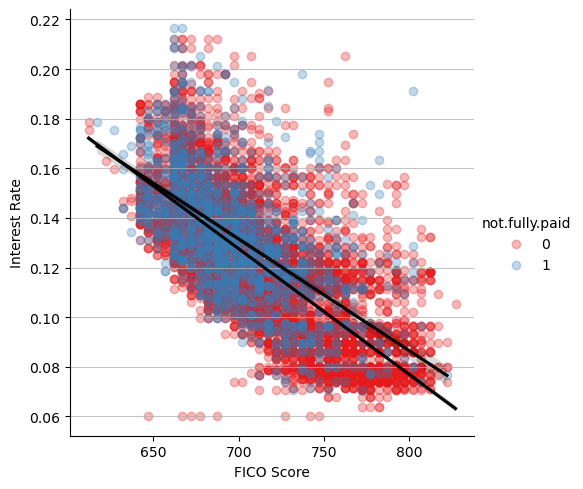

In [25]:
# is there a relationship between the Fqico score and the interest rate?
plt.figure(figsize=(10,6))
sns.lmplot(x='fico', y='int.rate', data=loans, hue='not.fully.paid', 
            palette='Set1', line_kws={'color': 'black'}, scatter_kws={'alpha':0.3})
plt.grid(axis='y', alpha=0.75)
plt.xlabel('FICO Score')
plt.ylabel('Interest Rate')

plt.show()

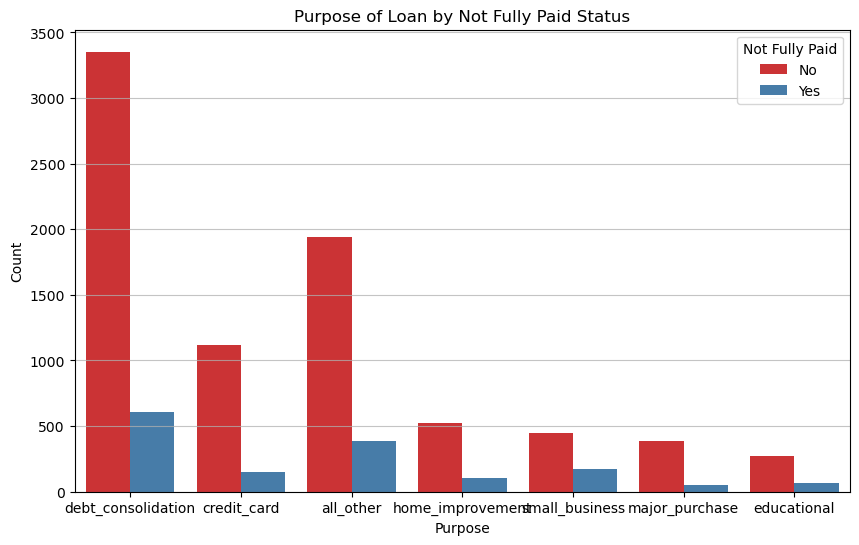

In [27]:
#plotting the histogram of the purpose of the loan with hue as not.fully.paid
plt.figure(figsize=(10,6))
sns.countplot(x='purpose', data=loans, 
              hue='not.fully.paid', palette='Set1')
plt.legend(loc='upper right', title='Not Fully Paid', labels=['No', 'Yes'])
plt.xlabel('Purpose')
plt.ylabel('Count')
plt.title('Purpose of Loan by Not Fully Paid Status')


plt.grid(axis='y', alpha=0.75)

plt.show()

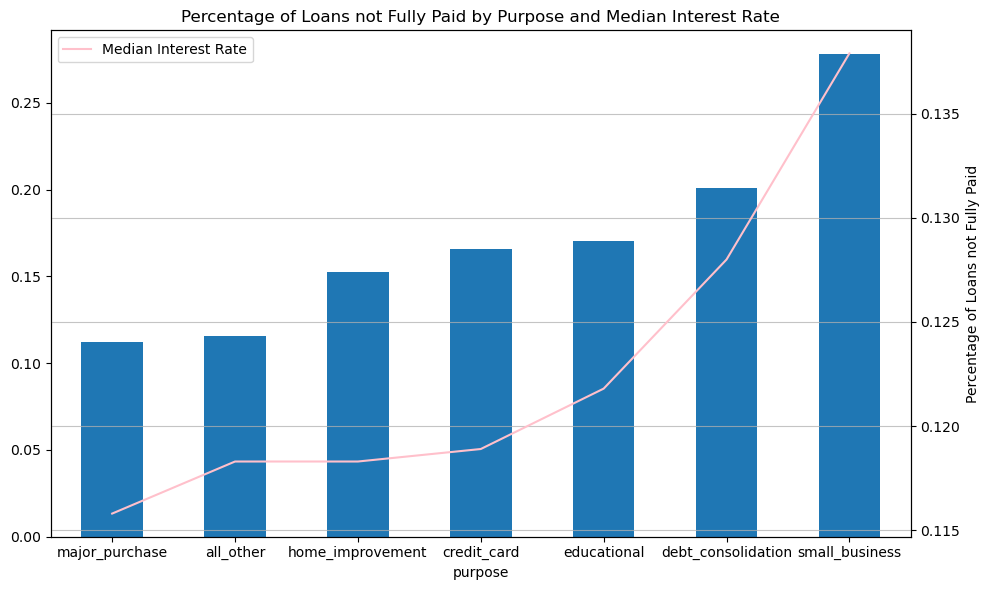

In [46]:
# Finding the percentage of loans that are not fully paid by purpose
loans.groupby('purpose')['not.fully.paid'].mean().sort_values().plot(kind='bar', figsize=(10,6))
loans.groupby('purpose')['int.rate'].median().sort_values().plot(kind='line', figsize=(10,6), secondary_y=True, color='pink')
plt.xlabel('Purpose')

plt.legend(['Median Interest Rate'], loc='upper left')
plt.ylabel('Percentage of Loans not Fully Paid')
plt.title('Percentage of Loans not Fully Paid by Purpose and Median Interest Rate')
plt.tight_layout()
plt.grid(axis='y', alpha=0.75)
plt.show()

# Setting up the Data

In [47]:
# check loans.info() to see the data types of the columns
loans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   object 
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  not.fully.paid     9578 non-null   int64  
dtypes: float64(6), int64(7), object(1)
memory usage: 1.0+ MB


# Dealing with Categorical Features 
- Purpose

In [ ]:
# Convert the purpose column to a dummy variable


In [52]:
loans = pd.get_dummies(loans, columns=['purpose'], drop_first=True, 
                       prefix='purpose', prefix_sep='_',dtype=int)
loans.head()

,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_major_purchase,purpose_small_business
0,1,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0,0,1,0,0,0,0
1,1,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0,1,0,0,0,0,0
2,1,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0,0,1,0,0,0,0
3,1,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0,0,1,0,0,0,0
4,1,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0,1,0,0,0,0,0


# Train Test Split

In [53]:
from sklearn.model_selection import train_test_split

In [54]:
X = loans.drop('not.fully.paid', axis=1)
y = loans['not.fully.paid'] # target variable
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

# Make single tree first

In [55]:
from sklearn.tree import DecisionTreeClassifier

In [56]:
# Create an instance of DecisionTreeClassifier
dtree = DecisionTreeClassifier()

In [57]:
dtree.fit(X_train, y_train)

DecisionTreeClassifier()

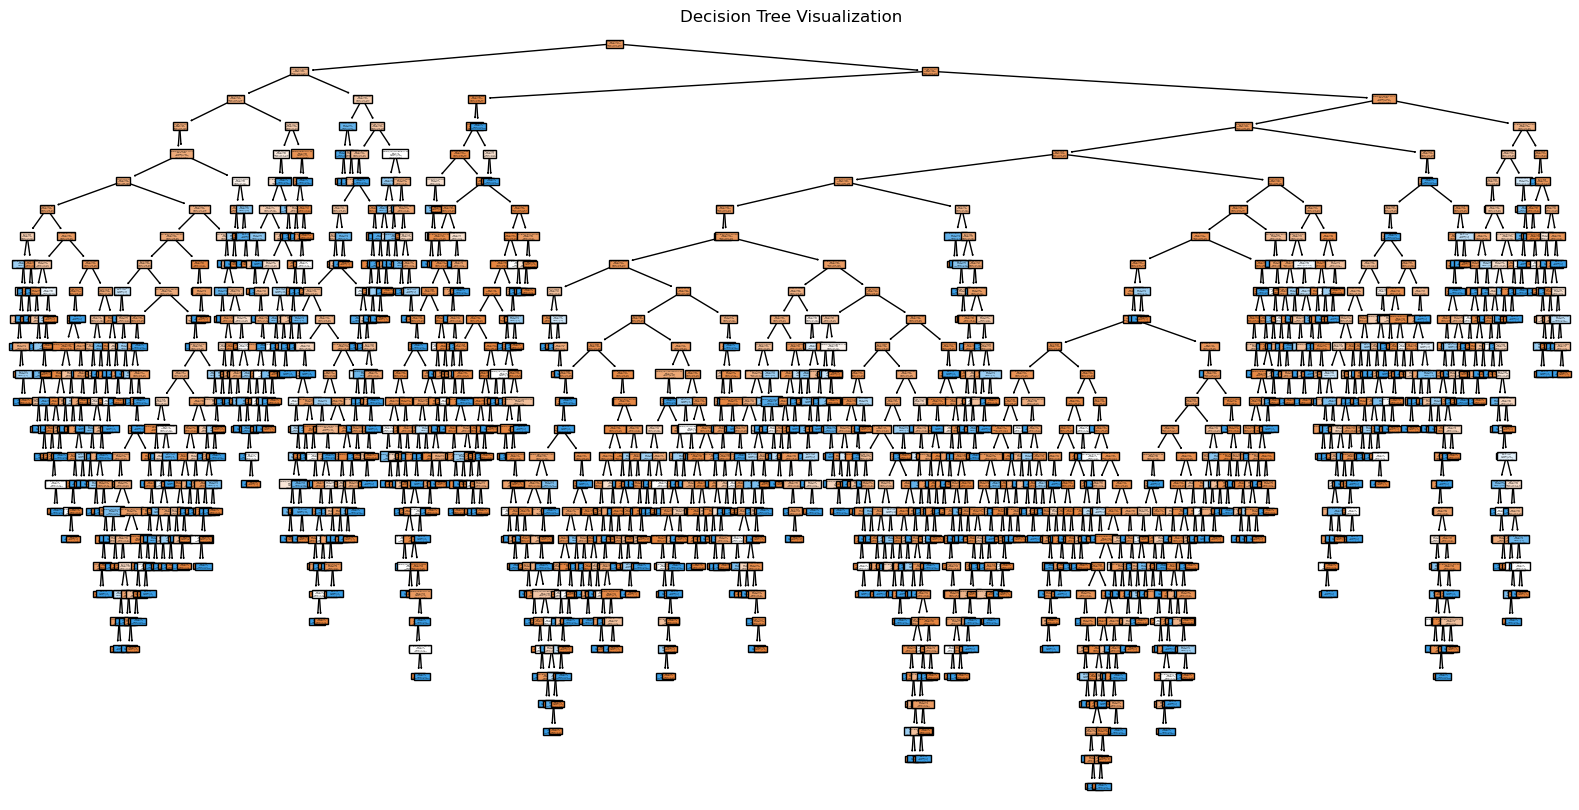

In [ ]:
# creating a visualization of the tree
from sklearn.tree import plot_tree
plt.figure(figsize=(20,10))
plot_tree(dtree, filled=True, feature_names=X.columns, 
          class_names=['Fully Paid', 'Not Fully Paid'])
plt.title("Decision Tree Visualization")
plt.show()


In [61]:
depth = dtree.get_depth()
print(f'The depth of the tree is: {depth}')

The depth of the tree is: 27


For a depth of 27, the tree shall overfit and is not even interpretable. Anyway lets first proceed with its predictions and evaluations

In [62]:
# Making predictions
predictions = dtree.predict(X_test)


In [63]:
# Evaluating the model
from sklearn.metrics import classification_report, confusion_matrix
print("Confusion Matrix: \n`", confusion_matrix(y_test, predictions))
print("\nClassification Report: \n", classification_report(y_test, predictions))

Confusion Matrix: 
` [[1994  437]
 [ 340  103]]

Classification Report: 
               precision    recall  f1-score   support

           0       0.85      0.82      0.84      2431
           1       0.19      0.23      0.21       443

    accuracy                           0.73      2874
   macro avg       0.52      0.53      0.52      2874
weighted avg       0.75      0.73      0.74      2874



# Hyperparameter Tuning of the D Tree

In [64]:
#Hyperparameter Tuning of Decision Tree
from sklearn.model_selection import GridSearchCV
# Create a dictionary of hyperparameters to search
param_grid = {'criterion': ['gini', 'entropy'],
              'splitter': ['best', 'random'],
              'max_depth': [None, 5, 10, 15, 20],
              'min_samples_split': [2, 5, 10, 15, 20],
              'min_samples_leaf': [1, 2, 5, 10, 15]}
# Create a GridSearchCV object
grid_tree = GridSearchCV(DecisionTreeClassifier(), param_grid, cv=5, verbose=2) 
# verbose is just for the output display
#cv is the number of folds for cross-validation
# Fit the model
grid_tree.fit(X_train, y_train)


Fitting 5 folds for each of 500 candidates, totalling 2500 fits
[CV] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=2, splitter=best; total time=   0.1s
[CV] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=2, splitter=best; total time=   0.0s
[CV] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=2, splitter=best; total time=   0.0s
[CV] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=2, splitter=best; total time=   0.0s
[CV] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=2, splitter=best; total time=   0.0s
[CV] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=2, splitter=random; total time=   0.0s
[CV] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=2, splitter=random; total time=   0.0s
[CV] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=2, splitter=random; total time=   0.0s
[C

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 5, 10, 15, 20],
                         'min_samples_leaf': [1, 2, 5, 10, 15],
                         'min_samples_split': [2, 5, 10, 15, 20],
                         'splitter': ['best', 'random']},
             verbose=2)

In [65]:
# Find the best hyperparameters
best_params = grid_tree.best_params_
print("Best hyperparameters:", best_params)

Best hyperparameters: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 15, 'min_samples_split': 15, 'splitter': 'random'}


In [66]:
# Making the decision tree model with the best hyperparameters
best_tree = DecisionTreeClassifier(criterion=best_params['criterion'],
                                    splitter=best_params['splitter'],
                                    max_depth=best_params['max_depth'],
                                    min_samples_split=best_params['min_samples_split'],
                                    min_samples_leaf=best_params['min_samples_leaf'])
best_tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, min_samples_leaf=15, min_samples_split=15,
                       splitter='random')

In [67]:
# Making predictions
best_predictions = best_tree.predict(X_test)

# Evaluate the Best Tree

In [68]:
# Evaluating the model
print("Confusion Matrix: \n", confusion_matrix(y_test, best_predictions))
print("\nClassification Report: \n", classification_report(y_test, best_predictions))

Confusion Matrix: 
 [[2416   15]
 [ 433   10]]

Classification Report: 
               precision    recall  f1-score   support

           0       0.85      0.99      0.92      2431
           1       0.40      0.02      0.04       443

    accuracy                           0.84      2874
   macro avg       0.62      0.51      0.48      2874
weighted avg       0.78      0.84      0.78      2874



# Accuracy is 84%. Not bad. Okay!
We could do better by a random forest perhaps

How does this tree looks like?

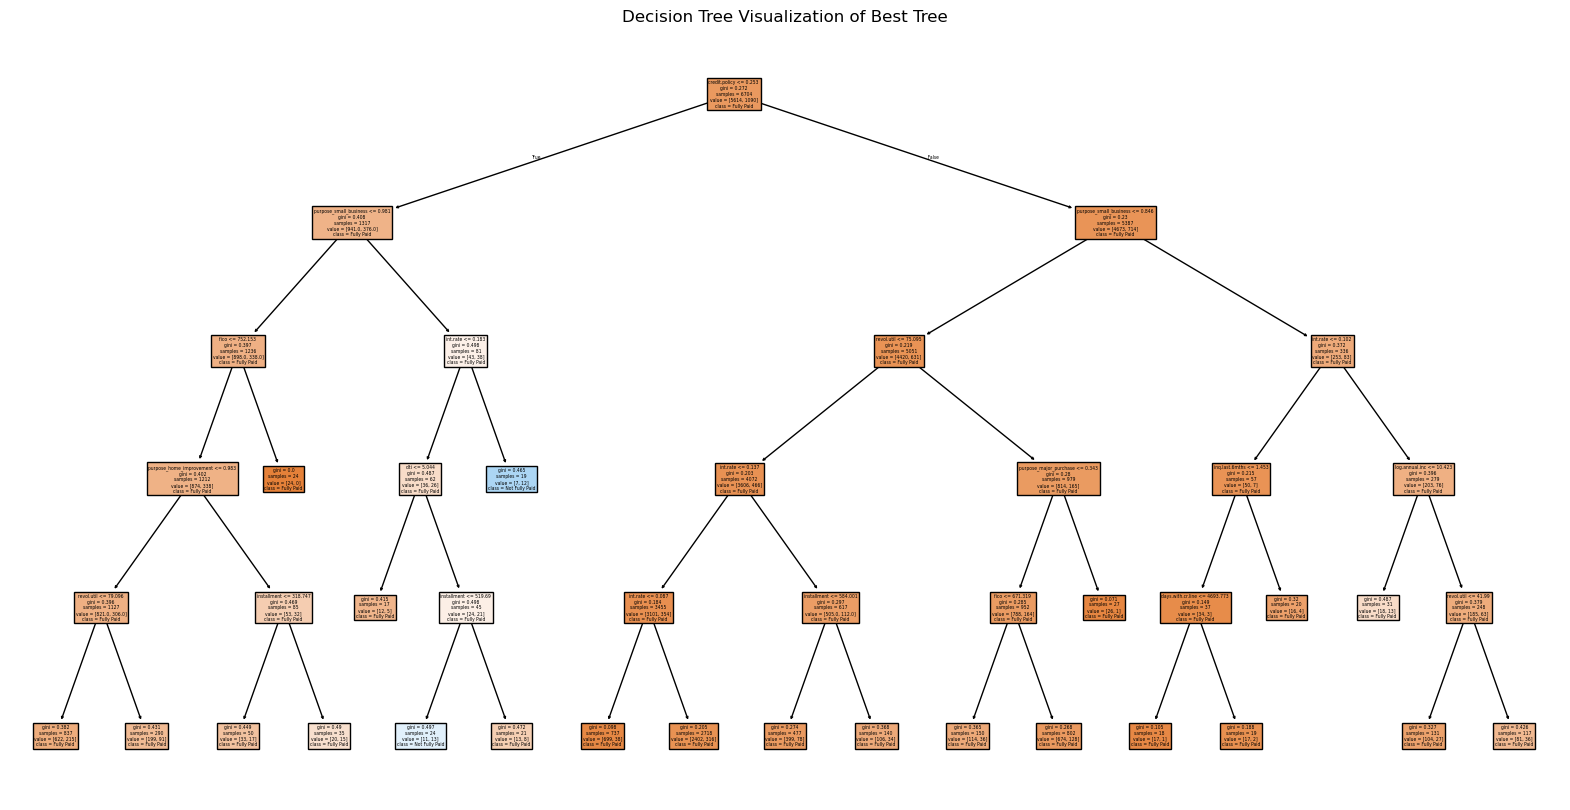

In [69]:
plt.figure(figsize=(20,10))
plot_tree(best_tree, filled=True, feature_names=X.columns, 
          class_names=['Fully Paid', 'Not Fully Paid'])
plt.title("Decision Tree Visualization of Best Tree")
plt.show()

# Creating a Random Forest now
Random forests have several advantages over decision trees, including better accuracy, robustness, and ability to handle large datasets. Random forests are also better at reducing overfitting. 


In [70]:
#importing the random forest classifier
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(n_estimators= 100) # n_estimators is number of trees in the forest

In [71]:
#fitting the model
rfc.fit(X_train, y_train)

RandomForestClassifier()

In [72]:
# Making predictions
rfc_predictions = rfc.predict(X_test)

In [73]:
#Evaluating the model
print("Confusion Matrix: \n", confusion_matrix(y_test, rfc_predictions))
print("\nClassification Report: \n", classification_report(y_test, rfc_predictions))

Confusion Matrix: 
 [[2424    7]
 [ 434    9]]

Classification Report: 
               precision    recall  f1-score   support

           0       0.85      1.00      0.92      2431
           1       0.56      0.02      0.04       443

    accuracy                           0.85      2874
   macro avg       0.71      0.51      0.48      2874
weighted avg       0.80      0.85      0.78      2874



# The Random Forest having 100 trees gives Accuracy of 85%. Its better than the tree.
Can we do better by Hyperparameter tuning?

In [74]:
# Hyperparameter Tuning of Random Forest
# Create a dictionary of hyperparameters to search
param_grid = {'n_estimators': [50, 100, 200],
              'criterion': ['gini', 'entropy'],
              'max_depth': [None, 5, 10, 15, 20],
              'min_samples_split': [2, 5, 10],
              'min_samples_leaf': [1, 2, 5]}
# Create a GridSearchCV object
grid_rfc = GridSearchCV(RandomForestClassifier(), param_grid, cv=5, verbose=2)

In [75]:
# Fit the model
grid_rfc.fit(X_train, y_train)

Fitting 5 folds for each of 270 candidates, totalling 1350 fits
[CV] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.4s
[CV] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.4s
[CV] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.4s
[CV] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.4s
[CV] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.4s
[CV] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.7s
[CV] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.7s
[CV] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total ti

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 5, 10, 15, 20],
                         'min_samples_leaf': [1, 2, 5],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200]},
             verbose=2)

In [77]:
# Find the best hyperparameters
best_params = grid_rfc.best_params_
print("Best hyperparameters:", best_params)

Best hyperparameters: {'criterion': 'gini', 'max_depth': 15, 'min_samples_leaf': 5, 'min_samples_split': 10, 'n_estimators': 100}


In [78]:
# Refit the model with the best hyperparameters
best_rfc = RandomForestClassifier(n_estimators=best_params['n_estimators'],
                                  criterion=best_params['criterion'],
                                  max_depth=best_params['max_depth'],
                                  min_samples_split=best_params['min_samples_split'],
                                  min_samples_leaf=best_params['min_samples_leaf'])
best_rfc.fit(X_train, y_train)

RandomForestClassifier(max_depth=15, min_samples_leaf=5, min_samples_split=10)

# Evaluating the BEST RF

In [79]:
# Making predictions
best_rfc_predictions = best_rfc.predict(X_test)

In [80]:
# model evaluation
confusion_mat = confusion_matrix(y_test, best_rfc_predictions)
class_report = classification_report(y_test, best_rfc_predictions)

print("Confusion Matrix: \n", confusion_mat)
print("\nClassification Report: \n", class_report)

Confusion Matrix: 
 [[2427    4]
 [ 440    3]]

Classification Report: 
               precision    recall  f1-score   support

           0       0.85      1.00      0.92      2431
           1       0.43      0.01      0.01       443

    accuracy                           0.85      2874
   macro avg       0.64      0.50      0.46      2874
weighted avg       0.78      0.85      0.78      2874



In [82]:
# best parameters
best_params = grid_rfc.best_params_
print("Best hyperparameters:")
for key in best_params:
    print(f'{key}: {best_params[key]}')

Best hyperparameters:
criterion: gini
max_depth: 15
min_samples_leaf: 5
min_samples_split: 10
n_estimators: 100


# Thus with the Best parameters we got Accuracy of 85%


# JOB Done!